# Lecture 4f — Would this pass a review?

**AI-powered Investment and Risk Management · Robo-Advisers and Automated Investment Platforms**

---

## The question

Five notebooks have built a robo-adviser one layer at a time. Each worked in isolation. This one
assembles them and asks the question a regulator asks:

> **Can you explain, reproduce, and defend every recommendation this system makes?**

ASIC's **RG 255** requires a licensee providing digital advice to retail clients to monitor and
test the algorithms that generate it, to have adequate technological and human resources, and to
be able to explain why a particular client received a particular recommendation. Those are not
abstract obligations. Each translates into an artefact you can build, and this notebook builds
three of them.

We then price the three ways robo-advisers have actually got into trouble — not hypothetical
failure modes, but the fact patterns behind real enforcement actions. The first turns out to cost
more than every modelling error in notebooks 4a to 4e combined.

## The layers

All six at once, plus the governance layer that sits underneath them and appears on no
architecture diagram.

---

### How to use this notebook

* Runs end to end in **under 15 seconds**. Self-contained: the pipeline is rebuilt in compact
  form so this notebook can be run without the others, though it will make much more sense after
  them.
* Exercises are tiered **Core** and **Stretch**.

> Regulatory material here is summarised for teaching and is current to the course materials, not
> to today. Verify the current position before relying on any of it.


## 0 · The pipeline, assembled

A compact reimplementation of notebooks 4a and 4b: a questionnaire, a scoring rule, a bucket
mapping, and a ladder of model portfolios. This is the whole product in about forty lines, which
is itself worth noticing.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.optimize import minimize

SEED, N_CLIENTS, FEE_BP = 20260811, 20_000, 25.0
rng = np.random.default_rng(SEED)

ITEMS   = ['experience', 'horizon', 'income_stability', 'risk_tolerance', 'knowledge']
WEIGHTS = pd.Series(dict(zip(ITEMS, [0.20, 0.20, 0.20, 0.25, 0.15])))
DIRECTION = pd.Series(dict(zip(ITEMS, [+1, +1, +1, +1, +1])))
LOADING = pd.Series(dict(zip(ITEMS, [0.55, 0.70, 0.45, 0.85, 0.50])))
NOISE   = pd.Series(dict(zip(ITEMS, [0.63, 0.53, 0.70, 0.42, 0.67])))
BUCKET_NAMES = ['Conservative', 'Moderately conservative', 'Moderate',
                'Moderately aggressive', 'Aggressive']

ASSETS = ['AU equity', 'Intl equity', 'EM equity', 'Agg bonds', 'Cash']
MU  = np.array([0.080, 0.075, 0.085, 0.042, 0.035])
SD  = np.array([0.160, 0.150, 0.210, 0.055, 0.008])
CORR = np.array([[1, .72, .66, .05, 0], [.72, 1, .74, .10, 0], [.66, .74, 1, .08, 0],
                 [.05, .10, .08, 1, .15], [0, 0, 0, .15, 1]])
COV = np.outer(SD, SD) * CORR
RF, MU_EXCESS, VAR_EQ = 0.035, 0.045, 0.16 ** 2
BUDGET, LONGONLY = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}], [(0.0, 1.0)] * 5

NAVY, BAND, RED, GREY, GOLD = '#123F69', '#E2EBF4', '#C0392B', '#7F8C8D', '#B7950B'
TEMPLATE = dict(layout=go.Layout(
    font=dict(family='Georgia, serif', size=13), plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#EEEEEE', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='#EEEEEE', zeroline=False),
    margin=dict(l=60, r=30, t=60, b=50)))


def to_common_scale(responses):
    d = responses.copy()
    d['horizon'] = np.interp(d['horizon'], (1, 20), (1, 5))
    for item in ITEMS:
        d[item] = np.where(DIRECTION[item] > 0, d[item], 6 - d[item])
    return d[ITEMS]

def risk_score(responses):
    return (to_common_scale(responses) * WEIGHTS.values).sum(axis=1).to_numpy()

def optimise(gamma, m=MU, S=COV):
    return minimize(lambda w: -(w @ m - gamma / 2 * w @ S @ w), np.repeat(0.2, 5),
                    method='SLSQP', bounds=LONGONLY, constraints=BUDGET).x

def utility(w, gamma):
    return float(w @ MU - gamma / 2 * w @ COV @ w)

def make_population(seed, n=N_CLIENTS):
    r = np.random.default_rng(seed)
    g_med = MU_EXCESS / (0.55 * VAR_EQ)
    log_g = np.log(g_med) + 0.42 * r.normal(size=n)
    gamma = np.clip(np.exp(log_g), 1.9, 20.0)
    z = (np.log(g_med) - log_g) / 0.42
    out = {}
    for item in ITEMS:
        latent = LOADING[item] * z + NOISE[item] * r.normal(size=n)
        out[item] = (np.clip(np.round(10 + 4.5 * latent), 1, 20) if item == 'horizon'
                     else np.clip(np.round(3 + latent), 1, 5))
    return pd.DataFrame(out), gamma

responses, gamma = make_population(SEED)
scores = risk_score(responses)
CUTS = np.quantile(scores, [0.2, 0.4, 0.6, 0.8])
buckets = np.digitize(scores, CUTS) + 1
RUNG_GAMMA = np.quantile(gamma, np.linspace(0.05, 0.95, 5))[::-1]   # bucket 1 = most cautious
LADDER = np.array([optimise(g) for g in RUNG_GAMMA])

print("The product, end to end:\n")
for i, (g, w) in enumerate(zip(RUNG_GAMMA, LADDER), start=1):
    print(f"  {i}. {BUCKET_NAMES[i-1]:<24} gamma {g:5.2f}  equity {w[:3].sum():4.0%}  "
          f"{dict(zip(ASSETS, (w*100).round(0).astype(int)))}")
print(f"\n{N_CLIENTS:,} clients scored; bucket occupancy "
      f"{(pd.Series(buckets).value_counts(normalize=True).sort_index()*100).round(1).tolist()}%")

The product, end to end:

  1. Conservative             gamma  6.38  equity  31%  {'AU equity': np.int64(18), 'Intl equity': np.int64(11), 'EM equity': np.int64(2), 'Agg bonds': np.int64(33), 'Cash': np.int64(35)}
  2. Moderately conservative  gamma  4.11  equity  48%  {'AU equity': np.int64(27), 'Intl equity': np.int64(16), 'EM equity': np.int64(4), 'Agg bonds': np.int64(48), 'Cash': np.int64(5)}
  3. Moderate                 gamma  3.22  equity  59%  {'AU equity': np.int64(33), 'Intl equity': np.int64(20), 'EM equity': np.int64(6), 'Agg bonds': np.int64(41), 'Cash': np.int64(0)}
  4. Moderately aggressive    gamma  2.51  equity  73%  {'AU equity': np.int64(40), 'Intl equity': np.int64(24), 'EM equity': np.int64(8), 'Agg bonds': np.int64(27), 'Cash': np.int64(0)}
  5. Aggressive               gamma  1.90  equity  92%  {'AU equity': np.int64(51), 'Intl equity': np.int64(29), 'EM equity': np.int64(12), 'Agg bonds': np.int64(8), 'Cash': np.int64(0)}

20,000 clients scored; bucket occupan

---

## 1 · Artefact one — reproducibility

The first question in any review is whether the system does the same thing twice. This sounds
trivial and is not: an unseeded random draw anywhere in the pipeline, a dictionary iteration
order, a library upgrade that changes a default, or a model retrained on newer data will all
break it. A recommendation you cannot reproduce is a recommendation you cannot defend.

In [2]:
def recommend(responses_df):
    """The full pipeline: responses in, portfolio out. Deterministic by construction."""
    s = risk_score(responses_df)
    b = np.digitize(s, CUTS) + 1
    return s, b, LADDER[b - 1]

test_client = pd.DataFrame({'experience': [4], 'horizon': [15], 'income_stability': [2],
                            'risk_tolerance': [4], 'knowledge': [3]})

runs = [recommend(test_client) for _ in range(5)]
identical = all(np.allclose(runs[0][2], r[2]) for r in runs)
print(f"Same client, five calls: identical portfolio -> {identical}")
print(f"Score {runs[0][0][0]:.4f}, bucket {runs[0][1][0]}, "
      f"equity {runs[0][2][0][:3].sum():.1%}")

# the same population, regenerated from the same seed
resp2, gamma2 = make_population(SEED)
print(f"\nPopulation regenerated from seed {SEED}: responses identical -> "
      f"{responses.equals(resp2)}, risk aversion identical -> {np.allclose(gamma, gamma2)}")

# recalibrating the cut points on a NEW cohort re-buckets existing clients
resp3, _ = make_population(SEED + 1)
cuts_stable = np.quantile(risk_score(resp3), [0.2, 0.4, 0.6, 0.8])
moved_stable = (np.digitize(scores, cuts_stable) + 1 != buckets).mean()

shifted = resp3.copy()                       # a campaign brings in bolder clients
shifted['risk_tolerance'] = np.clip(shifted['risk_tolerance'] + 1, 1, 5)
shifted['horizon'] = np.clip(shifted['horizon'] + 5, 1, 20)
cuts_shifted = np.quantile(risk_score(shifted), [0.2, 0.4, 0.6, 0.8])
moved_shifted = (np.digitize(scores, cuts_shifted) + 1 != buckets).mean()

print(f"\nRecalibrating the cut points on a NEW cohort, existing clients' answers unchanged:")
print(f"  new cohort similar to the old one : {moved_stable:5.1%} of clients change bucket")
print(f"  new cohort is bolder (a campaign) : {moved_shifted:5.1%} of clients change bucket")
print(f"  cut points {np.round(CUTS,2)} -> {np.round(cuts_shifted,2)}")

Same client, five calls: identical portfolio -> True
Score 3.4395, bucket 4, equity 72.6%

Population regenerated from seed 20260811: responses identical -> True, risk aversion identical -> True

Recalibrating the cut points on a NEW cohort, existing clients' answers unchanged:
  new cohort similar to the old one :  1.5% of clients change bucket
  new cohort is bolder (a campaign) : 73.6% of clients change bucket
  cut points [2.4  2.81 3.14 3.55] -> [2.86 3.27 3.61 4.  ]


The last result is the one that matters and it is easy to miss. The scoring function is
deterministic, but the **cut points are calibrated on a client population**, so they move as the
population moves. When the incoming cohort resembles the existing book this is harmless — barely
one client in seventy shifts. When the cohort is different, a large share of existing clients
silently change bucket, and therefore change portfolio, without answering a single question
differently.

This is the coupling that makes reproducibility hard. The individual recommendation is a pure
function of the answers *and the parameters in force at the time*, and only the first half is
stored. A platform that recalibrates quarterly and does not version its cut points cannot
reconstruct why a client held what they held in a given quarter. That is a records problem before it is a
modelling problem, and the fix is cheap: version the cut points, store them with the
recommendation, and never recompute a historical recommendation with current parameters.

---

## 2 · Artefact two — explainability

RG 255 expects a licensee to be able to explain a specific recommendation to a specific client.
Because the scoring rule is a weighted sum, the explanation is exact rather than approximate: each
item's contribution is its scaled response times its weight. No surrogate model, no
attribution method with its own assumptions.

This is a genuine advantage of the simple design that notebook 4b defended on statistical
grounds. It happens to be the design that is easiest to explain, and those two facts are not a
coincidence.

In [3]:
def explain(responses_df, i=0):
    """Exact decomposition of one client's recommendation."""
    scaled = to_common_scale(responses_df).iloc[i]
    contrib = (scaled * WEIGHTS).sort_values(ascending=False)
    s, b, w = recommend(responses_df)
    lines = [f"Recommendation: portfolio {b[i]} - {BUCKET_NAMES[b[i]-1]}",
             f"Risk score {s[i]:.2f}, placing this client in band "
             f"{'below ' + format(CUTS[0], '.2f') if s[i] < CUTS[0] else ''}"
             f"{'above ' + format(CUTS[-1], '.2f') if s[i] > CUTS[-1] else ''}"
             f"{next((f'{lo:.2f} to {hi:.2f}' for lo, hi in zip(CUTS[:-1], CUTS[1:]) if lo <= s[i] <= hi), '')}",
             "", "How the score was built:"]
    for item, c in contrib.items():
        raw = responses_df.iloc[i][item]
        lines.append(f"   {item:<18} answer {raw:>5}  ->  scaled {scaled[item]:.2f} "
                     f"x weight {WEIGHTS[item]:.2f}  =  {c:.3f}")
    lines += ["", f"   {'TOTAL':<18} {' ' * 34}{contrib.sum():.3f}", "",
              "Resulting allocation:"]
    for a, x in zip(ASSETS, w[i]):
        if x > 0.005:
            lines.append(f"   {a:<14} {x:6.1%}")
    lines.append(f"\nMoving any single answer by one point would change the score by at most "
                 f"{WEIGHTS.max():.2f},")
    nearest = min(abs(s[i] - CUTS)) if len(CUTS) else 9
    lines.append(f"and this client sits {nearest:.2f} from the nearest band boundary - "
                 f"{'a change of one answer would move them' if nearest < WEIGHTS.max() else 'no single answer would move them'}.")
    return "\n".join(lines)

print(explain(test_client))

Recommendation: portfolio 4 - Moderately aggressive
Risk score 3.44, placing this client in band 3.14 to 3.55

How the score was built:
   risk_tolerance     answer     4  ->  scaled 4.00 x weight 0.25  =  1.000
   experience         answer     4  ->  scaled 4.00 x weight 0.20  =  0.800
   horizon            answer    15  ->  scaled 3.95 x weight 0.20  =  0.789
   knowledge          answer     3  ->  scaled 3.00 x weight 0.15  =  0.450
   income_stability   answer     2  ->  scaled 2.00 x weight 0.20  =  0.400

   TOTAL                                                3.439

Resulting allocation:
   AU equity       40.0%
   Intl equity     24.4%
   EM equity        8.2%
   Agg bonds       27.4%

Moving any single answer by one point would change the score by at most 0.25,
and this client sits 0.11 from the nearest band boundary - a change of one answer would move them.


The final line is the part most explanation tools omit and the part a client would most want to
know: **how close was this to going the other way?** Notebook 4a measured that roughly half of all
clients sit within one answer of a different bucket. An explanation that presents the
recommendation as settled, when a single answer would have changed it, is accurate and
misleading at the same time.

A defensible product surfaces the proximity. "You are close to the boundary with the balanced
portfolio; here is what that would look like" is both better advice and a better record.

---

## 3 · Artefact three — drift monitoring

Algorithms are monitored, not merely tested once. The population arriving through the front door
changes — a marketing campaign, a new distribution channel, a market crash — and a questionnaire
calibrated on last year's clients may be badly calibrated for this year's.

The standard instrument is the **population stability index**.

<details>
<summary><b>Population stability index (click to open)</b></summary>

Given a reference distribution split into bins with proportions $r_k$ and a current distribution
with proportions $c_k$,

$$\text{PSI} = \sum_k (c_k - r_k)\ln\!\frac{c_k}{r_k}$$

It is the symmetrised Kullback–Leibler divergence between the two, and the conventional reading
is: below 0.10 no meaningful shift, 0.10 to 0.25 moderate shift worth investigating, above 0.25
material shift requiring action.

The thresholds are conventions from credit scoring, not laws. What makes PSI useful is not the
number but the fact that it is computed and logged every month, so a shift is noticed while it is
still small.
</details>

In [4]:
def psi(reference, current, bins=10):
    edges = np.quantile(reference, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    r = np.histogram(reference, edges)[0] / len(reference)
    c = np.histogram(current,  edges)[0] / len(current)
    r, c = np.clip(r, 1e-6, None), np.clip(c, 1e-6, None)
    return float(np.sum((c - r) * np.log(c / r)))

# three scenarios for next year's intake
scenarios = {}
r_base, _ = make_population(SEED + 7, n=8000)
scenarios['Business as usual'] = risk_score(r_base)

r_young = r_base.copy()                      # a campaign that attracts bolder, younger clients
r_young['horizon'] = np.clip(r_young['horizon'] + 5, 1, 20)
r_young['risk_tolerance'] = np.clip(r_young['risk_tolerance'] + 1, 1, 5)
scenarios['Campaign: younger cohort'] = risk_score(r_young)

r_crash = r_base.copy()                      # intake during a drawdown: everyone reports lower tolerance
r_crash['risk_tolerance'] = np.clip(r_crash['risk_tolerance'] - 1, 1, 5)
r_crash['experience'] = np.clip(r_crash['experience'] - 1, 1, 5)
scenarios['Intake during a crash'] = risk_score(r_crash)

rows = []
for name, s in scenarios.items():
    b = np.digitize(s, CUTS) + 1
    occ = pd.Series(b).value_counts(normalize=True).reindex(range(1, 6)).fillna(0) * 100
    rows.append({'Scenario': name, 'PSI': round(psi(scores, s), 3),
                 'Reading': 'stable' if psi(scores, s) < 0.10 else
                            ('investigate' if psi(scores, s) < 0.25 else 'ACTION'),
                 'Mean equity issued': f"{(LADDER[b-1][:, :3].sum(axis=1)).mean():.1%}",
                 'Bucket mix %': np.round(occ.values, 0).astype(int).tolist()})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nReference bucket mix (current book): "
      f"{np.round(pd.Series(buckets).value_counts(normalize=True).sort_index().values*100, 0).astype(int).tolist()}")

                Scenario   PSI Reading Mean equity issued         Bucket mix %
       Business as usual 0.002  stable              60.8% [20, 20, 19, 21, 20]
Campaign: younger cohort 0.432  ACTION              73.7%  [6, 12, 15, 24, 44]
   Intake during a crash 0.418  ACTION              48.4%  [42, 24, 15, 12, 6]

Reference bucket mix (current book): [20, 20, 20, 20, 20]


The crash scenario is the one worth dwelling on. Clients assessed during a drawdown report
lower risk tolerance — that is well documented and entirely human — and the questionnaire, doing
exactly what it was built to do, places them in more conservative portfolios. They then hold
those portfolios through the recovery.

The system has not malfunctioned. It has faithfully recorded a preference that was measured at
the worst possible moment, and then locked it in. Whether that is good advice is a question the
algorithm cannot ask itself, which is precisely why RG 255 requires a human to be monitoring the
output.

---

## 4 · Failure mode one — undisclosed allocation

Now the three ways this actually goes wrong in practice. The first is the largest, and it
involves no modelling error at all.

A platform advertises zero advice fees and allocates a meaningful share of every portfolio to
cash, on which it earns the spread. Nothing is hidden in a legal sense: the allocation appears in
the disclosure. But the *cost* of it does not, because the cost is an opportunity cost.

This is the fact pattern in the SEC's 2022 settlement with Schwab over Intelligent Portfolios,
which carried a penalty of approximately US$187 million.

In [5]:
PORTFOLIO_RETURN = float(LADDER[2] @ MU)      # the moderate portfolio
CASH_PAID        = 0.020                      # what the platform credits on cash balances

def cash_drag_bp(cash_weight, portfolio_return=PORTFOLIO_RETURN, cash_paid=CASH_PAID):
    return cash_weight * (portfolio_return - cash_paid) * 1e4

weights = np.array([0.02, 0.06, 0.10, 0.15, 0.20, 0.30])
drag = np.array([cash_drag_bp(w) for w in weights])
print(f"Moderate portfolio expected return {PORTFOLIO_RETURN:.2%}, "
      f"cash credited at {CASH_PAID:.2%}\n")
print(pd.DataFrame({'Cash allocation': [f"{w:.0%}" for w in weights],
                    'Cost to client (bp p.a.)': drag.round(0).astype(int),
                    'As a multiple of a 25 bp fee': [f"{d/FEE_BP:.1f}x" for d in drag]}
                   ).to_string(index=False))
break_even = FEE_BP / ((PORTFOLIO_RETURN - CASH_PAID) * 1e4)
print(f"\nA cash allocation of {break_even:.1%} costs exactly as much as the "
      f"{FEE_BP:.0f} bp fee it replaces.")
print(f"Above that, 'zero fee' is more expensive than paying the fee.")

Moderate portfolio expected return 6.37%, cash credited at 2.00%

Cash allocation  Cost to client (bp p.a.) As a multiple of a 25 bp fee
             2%                         9                         0.3x
             6%                        26                         1.0x
            10%                        44                         1.7x
            15%                        66                         2.6x
            20%                        87                         3.5x
            30%                       131                         5.2x

A cash allocation of 5.7% costs exactly as much as the 25 bp fee it replaces.
Above that, 'zero fee' is more expensive than paying the fee.


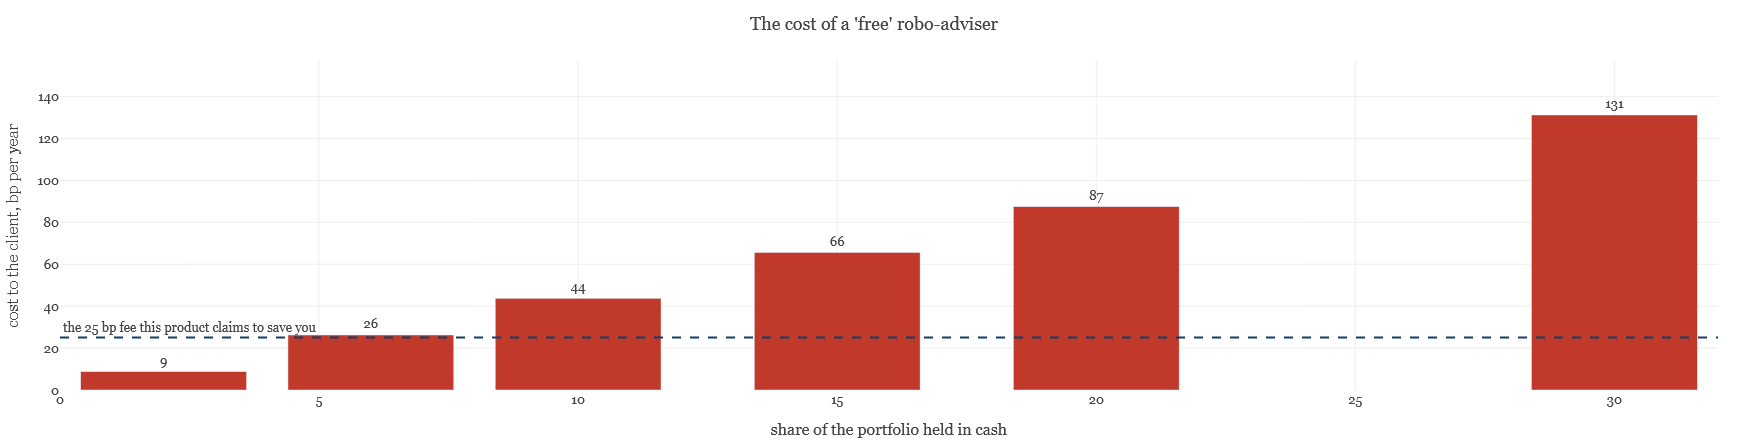

In [6]:
fig = go.Figure()
fig.add_trace(go.Bar(x=[f"{w:.0%}" for w in weights], y=drag, marker_color=RED,
                     text=[f"{d:.0f}" for d in drag], textposition='outside', name='cash drag',
                     hovertemplate='cash %{x}<br>%{y:.0f} bp p.a.<extra></extra>'))
fig.add_hline(y=FEE_BP, line=dict(color=NAVY, width=2, dash='dash'),
              annotation_text=f'the {FEE_BP:.0f} bp fee this product claims to save you',
              annotation_position='top left')
fig.update_layout(template=TEMPLATE, height=440, showlegend=False,
                  title_text="The cost of a 'free' robo-adviser",
                  xaxis_title='share of the portfolio held in cash',
                  yaxis_title='cost to the client, bp per year',
                  yaxis_range=[0, drag.max() * 1.2])
fig.show()

A cash allocation in the high single digits wipes out the fee it claims to save. A cash
allocation of 30% — the upper end of what Schwab's most conservative profiles held — costs several
times the fee.

This is the single largest controllable number anywhere in these six notebooks. It dwarfs the
elicitation error, the ladder discretisation, the rebalancing rule, and the tax engine. And
unlike all of those, it is not a modelling difficulty or a statistical limitation. It is a product
decision, made deliberately, in favour of the platform.

The audit question is therefore not "is the allocation disclosed?" but **"is the cost of the
allocation disclosed, in basis points, in a place the client will read?"** Those are different
questions and only the second one protects anybody.

---

## 5 · Failure mode two — the silent code defect

The second failure mode produces no error, no exception, and no anomalous output. The system runs
perfectly and gives the wrong answer.

We invert the direction of one questionnaire item — a single character in the source — and price
the result.

In [7]:
def rerun_with_direction(item, sign):
    global DIRECTION
    saved = DIRECTION.copy()
    DIRECTION[item] = sign
    s = risk_score(responses)
    b = np.digitize(s, CUTS) + 1
    DIRECTION = saved
    return s, b

s_bad, b_bad = rerun_with_direction('income_stability', -1)
w_good, w_bad = LADDER[buckets - 1], LADDER[b_bad - 1]

cost = np.array([utility(a, g) - utility(bq, g) for a, bq, g in zip(w_good, w_bad, gamma)]) * 1e4
changed = (b_bad != buckets)

print(f"Clients placed in a different bucket:        {changed.mean():.1%}")
print(f"Clients moved two or more buckets:           {(np.abs(b_bad - buckets) >= 2).mean():.1%}")
print(f"Mean cost across the whole client base:      {cost.mean():.1f} bp p.a.")
print(f"Mean cost among clients actually affected:   {cost[changed].mean():.1f} bp p.a.")
print(f"90th percentile of cost:                     {np.quantile(cost, 0.90):.1f} bp p.a.")
print(f"99th percentile of cost:                     {np.quantile(cost, 0.99):.0f} bp p.a.")
print(f"Worst affected client:                       {cost.max():.0f} bp p.a.")
print(f"Clients harmed by more than the {FEE_BP:.0f} bp fee:    {(cost > FEE_BP).mean():.1%}")
print(f"\nNothing in the output announces the defect. The scores stay in [1, 5], the")
print(f"buckets stay populated, every portfolio is a valid portfolio, and the")
print(f"bucket mix is {np.round(pd.Series(b_bad).value_counts(normalize=True).sort_index().values*100,0).astype(int).tolist()}% "
      f"against {np.round(pd.Series(buckets).value_counts(normalize=True).sort_index().values*100,0).astype(int).tolist()}% before.")

Clients placed in a different bucket:        43.2%
Clients moved two or more buckets:           5.6%
Mean cost across the whole client base:      1.4 bp p.a.
Mean cost among clients actually affected:   3.2 bp p.a.
90th percentile of cost:                     9.9 bp p.a.
99th percentile of cost:                     34 bp p.a.
Worst affected client:                       96 bp p.a.
Clients harmed by more than the 25 bp fee:    2.4%

Nothing in the output announces the defect. The scores stay in [1, 5], the
buckets stay populated, every portfolio is a valid portfolio, and the
bucket mix is [13, 24, 25, 25, 14]% against [20, 20, 20, 20, 20]% before.


Look carefully at what the numbers say, because the naive reading is wrong in both directions.

**The average harm is small.** Around 1.4 bp across the client base. Certainty-equivalent loss is
quadratic, so a client pushed one bucket in the wrong direction loses very little, and the errors
push in both directions and partly cancel in aggregate. Anyone defending the system would reach
for this number.

**The tail is severe and that is the number that matters.** A small share of clients lose more
than the entire advice fee, and the worst lose most of a percentage point a year — every year,
silently, with no mechanism by which they would ever find out. A compliance failure is not
assessed on its mean. You cannot tell the client at the 99th percentile that the average was fine.

**And the output looks completely normal.** The bucket mix shifts but remains entirely plausible:
no bucket is empty, no score is out of range, every portfolio is a valid portfolio. No amount of
output monitoring catches this, because there is nothing anomalous in the output to catch. What catches it is
the direction assertion from notebook 4a — three lines that bump each item and check the score
moves the declared way. That test costs nothing and belongs in continuous integration, running on
every commit.

The general principle: **assert the properties your model is supposed to have, not just the shape
of its output.** Monotonicity, direction, symmetry, and bounds are all cheaply testable and are
where silent defects live.

---

## 6 · Failure mode three — overstated capability

The third is a disclosure failure rather than a technical one. Claiming a capability the system
does not have — machine learning that turns out to be a lookup table, tax-loss harvesting quoted
at its naive value, a "personalised" portfolio that is one of five.

Notebooks 4b, 4d and 4e each measured the gap between a common claim and the measured reality.

In [8]:
claims = pd.DataFrame([
    {'Marketing claim': 'AI-driven portfolio construction',
     'What the system does': 'Constrained mean-variance, run offline, five outputs',
     'Measured gap': 'Bespoke optimisation is worth 1.1 bp p.a. (4b)'},
    {'Marketing claim': 'Personalised to your situation',
     'What the system does': 'One of five portfolios; ~49% of clients would land elsewhere on a retake',
     'Measured gap': 'Test-retest agreement 48.7% (4a)'},
    {'Marketing claim': 'Tax-loss harvesting adds ~1% a year',
     'What the system does': 'Deferral worth 2.8 bp p.a. under Australian rules',
     'Measured gap': 'Naive figure overstates by 6.1x (4d)'},
    {'Marketing claim': 'Machine learning optimises your returns',
     'What the system does': 'ML predicts client behaviour; allocation uses no ML',
     'Measured gap': 'Walk-forward return-prediction AUC 0.497 (4e)'},
    {'Marketing claim': 'Zero advice fee',
     'What the system does': 'Cash allocation earning the platform the spread',
     'Measured gap': f'10% cash costs {cash_drag_bp(0.10):.0f} bp p.a. (section 4)'}])
for _, r in claims.iterrows():
    print(f"CLAIM    {r['Marketing claim']}")
    print(f"  actual {r['What the system does']}")
    print(f"  gap    {r['Measured gap']}\n")

CLAIM    AI-driven portfolio construction
  actual Constrained mean-variance, run offline, five outputs
  gap    Bespoke optimisation is worth 1.1 bp p.a. (4b)

CLAIM    Personalised to your situation
  actual One of five portfolios; ~49% of clients would land elsewhere on a retake
  gap    Test-retest agreement 48.7% (4a)

CLAIM    Tax-loss harvesting adds ~1% a year
  actual Deferral worth 2.8 bp p.a. under Australian rules
  gap    Naive figure overstates by 6.1x (4d)

CLAIM    Machine learning optimises your returns
  actual ML predicts client behaviour; allocation uses no ML
  gap    Walk-forward return-prediction AUC 0.497 (4e)

CLAIM    Zero advice fee
  actual Cash allocation earning the platform the spread
  gap    10% cash costs 44 bp p.a. (section 4)



None of the claims in the left column is a lie exactly. Each describes something the system
genuinely contains. The problem is proportion: the claim implies the feature is doing most of the
work, and the measurement says it is doing a few basis points of it.

The Betterment settlement concerned misstatements about how tax-loss harvesting operated. The
regulatory risk here is not that the arithmetic is wrong; it is that the arithmetic was never
done, so nobody in the business knew what the feature was worth when they wrote the copy.

---

## 7 · The complete cost stack

Every number measured across the six notebooks, in one place, against the fee.

In [9]:
stack = pd.DataFrame([
    ('Ladder discretisation (4b)',          1.1,  'unavoidable, trivial'),
    ('Tax-loss harvesting, net (4d)',      -2.8,  'a benefit, if the client has gains'),
    ('Elicitation error (4a)',              7.1,  'reducible: recalibrate the ladder'),
    ('Behaviour model, captured (4e)',     -9.0,  'a benefit; capture rate is the constraint'),
    ('Rebalancing, 5pp band, taxable (4c)', 20.3, 'reducible: cash-flow rebalancing'),
    ('Advice fee',                          25.0, 'disclosed'),
    ('Cash drag at 10% (4f)',   cash_drag_bp(0.10), 'a product decision, not a limitation'),
    ('Panic selling, unaddressed (4e)',     41.0, 'the 50 bp problem, less the 9 bp captured'),
], columns=['Item', 'bp p.a.', 'Character'])
stack['bp p.a.'] = stack['bp p.a.'].round(1)
print(stack.to_string(index=False))
print(f"\nSum of costs, excluding the fee and the two benefits: "
      f"{stack[stack['bp p.a.'] > 0]['bp p.a.'].sum() - FEE_BP:.0f} bp p.a.")
top3 = stack[stack['Item'] != 'Advice fee'].nlargest(3, 'bp p.a.')['Item'].tolist()
print(f"Three largest items excluding the fee: {top3}")
print(f"Commercial, behavioural and operational - none of them statistical.")

                               Item  bp p.a.                                 Character
         Ladder discretisation (4b)      1.1                      unavoidable, trivial
      Tax-loss harvesting, net (4d)     -2.8        a benefit, if the client has gains
             Elicitation error (4a)      7.1         reducible: recalibrate the ladder
     Behaviour model, captured (4e)     -9.0 a benefit; capture rate is the constraint
Rebalancing, 5pp band, taxable (4c)     20.3          reducible: cash-flow rebalancing
                         Advice fee     25.0                                 disclosed
              Cash drag at 10% (4f)     43.7      a product decision, not a limitation
    Panic selling, unaddressed (4e)     41.0 the 50 bp problem, less the 9 bp captured

Sum of costs, excluding the fee and the two benefits: 113 bp p.a.
Three largest items excluding the fee: ['Cash drag at 10% (4f)', 'Panic selling, unaddressed (4e)', 'Rebalancing, 5pp band, taxable (4c)']
Commercial,

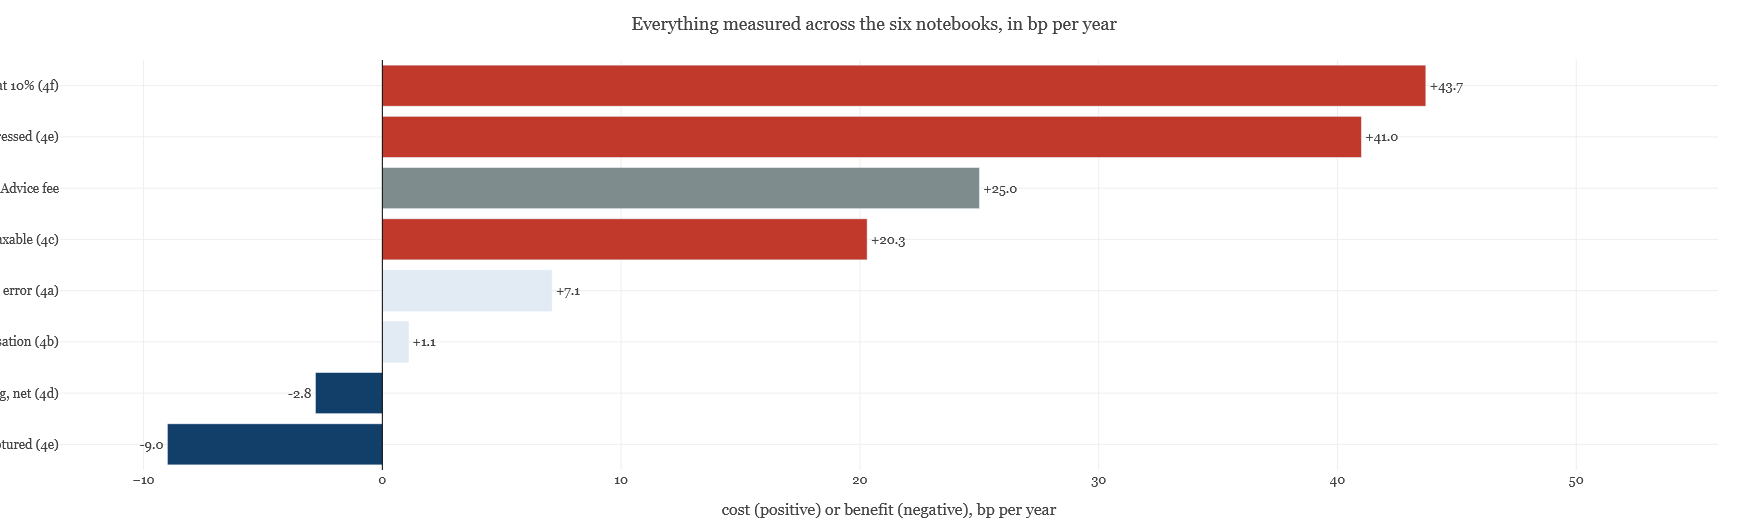

In [10]:
s = stack.sort_values('bp p.a.')
cols = [NAVY if v < 0 else (GREY if 'fee' in i.lower() else
        (RED if v > 20 else BAND)) for i, v in zip(s['Item'], s['bp p.a.'])]
fig = go.Figure(go.Bar(x=s['bp p.a.'], y=s['Item'], orientation='h', marker_color=cols,
                       text=[f"{v:+.1f}" for v in s['bp p.a.']], textposition='outside',
                       hovertemplate='%{y}<br>%{x:+.1f} bp p.a.<extra></extra>'))
fig.add_vline(x=0, line=dict(color='black', width=1))
fig.update_layout(template=TEMPLATE, height=520, showlegend=False,
                  title_text='Everything measured across the six notebooks, in bp per year',
                  xaxis_title='cost (positive) or benefit (negative), bp per year',
                  xaxis_range=[min(s['bp p.a.']) * 1.5, max(s['bp p.a.']) * 1.28])
fig.show()

## 8 · What the six notebooks add up to

**The statistical problems are the small ones.** Elicitation error, ladder discretisation and
tax mechanics together come to under ten basis points. They are the parts of the system that look
most like finance, attract the most academic attention, and are easiest to write code about.

**The large numbers are behavioural, operational and commercial.** Panic selling, the tax cost of
rebalancing in a taxable account, and the cash allocation are each several times any modelling
error. Two of the three are not modelling problems at all. The cash drag is a decision somebody
made in a meeting.

**The governance artefacts are cheap.** Reproducibility took a seed and versioned cut points.
Explainability came free from the linear scoring rule. Drift monitoring is one function. Together
they are perhaps a hundred lines, and they are the difference between a system you can defend and
one you cannot.

**The thesis holds, with a correction.** The lecture argues a robo-adviser is a
preference-elicitation and behaviour-management system with an optimiser bolted on, and the
measurements support it: the optimiser is worth about a basis point of refinement while the
behaviour layer addresses a fifty-basis-point problem. The correction is that the single largest
controllable item is neither elicitation nor behaviour. It is the cash allocation — a commercial
choice, invisible in the architecture diagram, that costs more than every model in the pipeline
combined.

**What none of this shows.** Every figure comes from a simulation whose parameters we chose. The
orderings are robust because they follow from mechanisms — quadratic utility loss makes small
allocation errors cheap, panic selling realises double-digit losses, cash earns less than
equities — but the specific basis points are properties of our assumptions. Nothing here is a
measurement of any real platform, and a real audit would begin by replacing every assumption in
section 0 with the licensee's own data.

---

## Exercises

### Core

**C1 · Audit the cut points.** Implement versioned cut points: store the calibration date and
parameters with each recommendation, and write a function that reconstructs a historical
recommendation exactly. Test it by recalibrating and confirming old recommendations are unchanged.

**C2 · Write the monitoring plan.** Draft the one-page algorithm monitoring plan an RG 255 review
would expect. Specify what is measured, how often, by whom, what thresholds trigger escalation,
and what the escalation is. Use the three artefacts in sections 1 to 3 as the technical content.

**C3 · Price your own product.** Rebuild the cost stack in section 7 for a platform of your
choice, using their published fees, cash allocations and disclosures. Which items can you fill in
from public information, and which cannot be determined from outside?

**C4 · The crash cohort.** Section 3 showed clients assessed during a drawdown are placed
conservatively and hold that through the recovery. Design the control. What would you monitor,
what would trigger a review, and what would you actually do about it without overriding a client's
stated preference?

### Stretch

**S1 · Adversarial questionnaire.** A client who wants the aggressive portfolio can work out which
answers produce it. Measure how many answers must be changed. Then design a questionnaire that is
harder to game without being harder to answer honestly.

**S2 · The full defect catalogue.** Write property-based tests for the whole pipeline:
monotonicity in each item, bucket ordering, ladder monotonicity in equity share, weights summing
to one, portfolios within bounds. Run them against deliberately mutated versions and report which
mutations survive.

**S3 · Whose fairness?** Section 3's crash scenario systematically issues conservative portfolios
to a cohort defined by *when they arrived*. Is that a fairness problem? Construct the argument
both ways and say what disclosure would make it acceptable.

**S4 · Sensitivity of the stack.** Identify the three assumptions in section 7 that the ordering
is most sensitive to. Vary each and report the range over which the top three items keep their
positions. Then state, in one paragraph, how much confidence the ordering deserves.

---

## Appendix · Reference

**Regulatory instruments.** ASIC **RG 255** *Providing digital financial product advice to retail
clients* — algorithm monitoring and testing, adequate resources, explainability of individual
recommendations. ASIC **REP 798** (October 2024) surveys AI governance across licensees. Referred
to for context: the SEC settlement with Charles Schwab over Intelligent Portfolios cash allocations
(2022, approximately US$187m) and the SEC action against Betterment concerning tax-loss harvesting
disclosures (2023). Details are summarised for teaching; verify current positions before relying
on them.

**The three artefacts.**

| Obligation | Artefact | Where |
|---|---|---|
| Reproduce a past recommendation | Seeded pipeline, versioned cut points | §1 |
| Explain an individual recommendation | Exact weight decomposition plus boundary proximity | §2 |
| Monitor the algorithm over time | Population stability index on the score distribution | §3 |

**Numbers carried in from the other notebooks.** Elicitation error 7.1 bp (4a); ladder
discretisation 1.1 bp (4b); rebalancing 20.3 bp on a 5pp band in a taxable account (4c); tax-loss
harvesting +2.8 bp net (4d); behaviour model +9 bp captured against a 50 bp problem, leaving 41 bp unaddressed (4e).